Crear una tabla
Las tablas en un metastore de Spark son abstracciones relacionales de archivos en el lago de datos. Las tablas pueden ser administradas por el metastore o ser externas y administradas independientemente del metastore.

Agregue una celda de código al cuaderno e ingrese el siguiente código, que guarda el DataFrame de datos de pedidos de venta como una tabla llamada salesorders 

In [2]:
from pyspark.sql.types import *

orderSchema = StructType([
    StructField("SalesOrderNumber", StringType()),
     StructField("SalesOrderLineNumber", IntegerType()),
     StructField("OrderDate", DateType()),
     StructField("CustomerName", StringType()),
     StructField("Email", StringType()),
     StructField("Item", StringType()),
     StructField("Quantity", IntegerType()),
     StructField("UnitPrice", FloatType()),
     StructField("Tax", FloatType())

])
df = spark.read.format("csv").schema(orderSchema).load('Files/orders/*.csv')
display(df)

StatementMeta(, b1a3706c-97d5-4fbf-9192-b44c4bd9ae16, 5, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 7ad3154b-3afa-4598-95c4-0d2155ebe120)

view temporal

In [3]:
# Crear la vista para usar con SQL
df.createOrReplaceTempView("v_orders")

# Ahora podés hacer una consulta SQL rápida para probar
spark.sql("SELECT CustomerName, SUM(Quantity) as TotalItems FROM v_orders GROUP BY CustomerName").show()

StatementMeta(, b1a3706c-97d5-4fbf-9192-b44c4bd9ae16, 6, Finished, Available, Finished, False)

+----------------+----------+
|    CustomerName|TotalItems|
+----------------+----------+
| Brianna Sanchez|         2|
|      Peter Deng|         1|
|   Kaitlyn James|         3|
|       Edwin Lal|         1|
|       Jorge Sun|         1|
|    Jocelyn Wood|         1|
|     Brandy Arun|         3|
|  Amanda Sanders|         4|
|  Clarence Huang|         3|
|  Elizabeth Wood|         5|
|   Christine Pal|         5|
|    Luke Coleman|         6|
|Jessica Peterson|         6|
|      Roger Chen|         3|
|       Austin Li|         2|
|    Jasmine Long|         2|
|      Bruce Suri|         3|
|      Eric Adams|         3|
|   Isabella Ward|         8|
|     Anna Flores|         2|
+----------------+----------+
only showing top 20 rows



In [9]:
 # Create a new table
 df.write.format("delta").saveAsTable("salesorders")

 # Get the table description
 spark.sql("DESCRIBE EXTENDED salesorders").show(truncate=False)

StatementMeta(, adf44236-9104-4e4e-a152-4bacb30489fd, 11, Finished, Available, Finished, False)

+----------------------------+-----------------------------------------------------------------------------------------------------------------------------------------+-------+
|col_name                    |data_type                                                                                                                                |comment|
+----------------------------+-----------------------------------------------------------------------------------------------------------------------------------------+-------+
|SalesOrderNumber            |string                                                                                                                                   |NULL   |
|SalesOrderLineNumber        |int                                                                                                                                      |NULL   |
|OrderDate                   |date                                                                                 

In [10]:
df = spark.sql("SELECT * FROM spark.dbo.salesorders LIMIT 1000")
display(df)

StatementMeta(, adf44236-9104-4e4e-a152-4bacb30489fd, 12, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 4c2aada9-abb8-4f5d-83b5-00159eef7bf3)

In [11]:
%%sql
SELECT
YEAR(OrderDate) AS OrderYear,
SUM(UnitPrice * Quantity * Tax) AS GrossRevenue
FROM salesorders
GROUP BY YEAR(OrderDate)
ORDER BY OrderYear

StatementMeta(, adf44236-9104-4e4e-a152-4bacb30489fd, 13, Finished, Available, Finished, False)

<Spark SQL result set with 3 rows and 2 fields>

In [12]:
%%sql
SELECT * FROM salesorders

StatementMeta(, adf44236-9104-4e4e-a152-4bacb30489fd, 14, Finished, Available, Finished, False)

<Spark SQL result set with 1000 rows and 9 fields>

Comience a usar matplotlib


In [13]:
sqlQuery = "SELECT CAST(YEAR(OrderDate) AS CHAR(4)) AS OrderYear, \
                SUM((UnitPrice * Quantity) + Tax) AS GrossRevenue, \
                COUNT(DISTINCT SalesOrderNumber) AS YearlyCounts \
            FROM salesorders \
            GROUP BY CAST(YEAR(OrderDate) AS CHAR(4)) \
            ORDER BY OrderYear"
df_spark = spark.sql(sqlQuery)
df_spark.show()

StatementMeta(, adf44236-9104-4e4e-a152-4bacb30489fd, 16, Finished, Available, Finished, False)

+---------+--------------------+------------+
|OrderYear|        GrossRevenue|YearlyCounts|
+---------+--------------------+------------+
|     2019|   4172169.969970703|        1201|
|     2020|   6882259.268127441|        2733|
|     2021|1.1547835291696548E7|       12525|
+---------+--------------------+------------+



Este devuelve un DataFrame de Spark con los ingresos anuales y el número de pedidos. Para visualizar los datos en un gráfico, utilizaremos primero la biblioteca matplotlib de Python. Esta biblioteca es la base de muchas otras para la creación de gráficos y ofrece una gran flexibilidad.



StatementMeta(, adf44236-9104-4e4e-a152-4bacb30489fd, 25, Finished, Available, Finished, False)

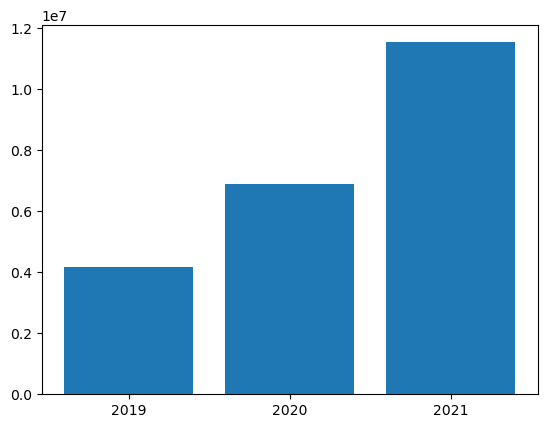

In [16]:
from matplotlib import pyplot as plt

#matpltlib requires a pandas dataFrame, not a spark one

df_sales = df_spark.toPandas()

#create a bar plot of revenue by year
plt.bar(x=df_sales['OrderYear'],height= df_sales['GrossRevenue'])

#display the plot
plt.show()





StatementMeta(, adf44236-9104-4e4e-a152-4bacb30489fd, 28, Finished, Available, Finished, False)

<Figure size 640x480 with 0 Axes>

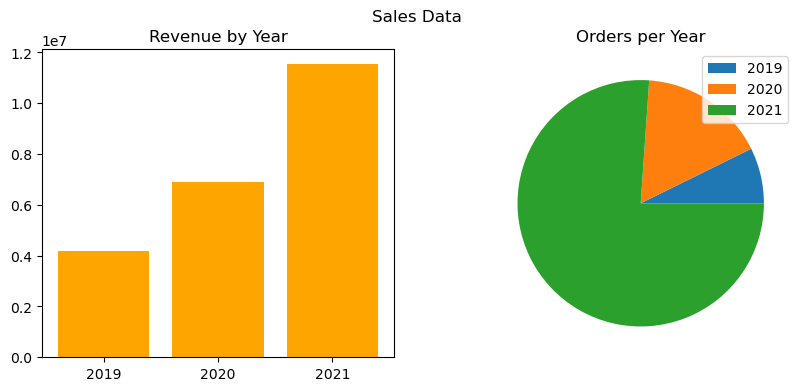

In [17]:
from matplotlib import pyplot as plt

# Clear the plot area
plt.clf()

# Create a figure for 2 subplots (1 row, 2 columns)
fig, ax = plt.subplots(1, 2, figsize = (10,4))

# Create a bar plot of revenue by year on the first axis
ax[0].bar(x=df_sales['OrderYear'], height=df_sales['GrossRevenue'], color='orange')
ax[0].set_title('Revenue by Year')

# Create a pie chart of yearly order counts on the second axis
ax[1].pie(df_sales['YearlyCounts'])
ax[1].set_title('Orders per Year')
ax[1].legend(df_sales['OrderYear'])

# Add a title to the Figure
fig.suptitle('Sales Data')

# Show the figure
plt.show()

Si bien Matplotlib permite crear diferentes tipos de gráficos, puede requerir código complejo para obtener los mejores resultados. Por esta razón, se han desarrollado nuevas bibliotecas basadas en Matplotlib para abstraer su complejidad y mejorar sus capacidades. Una de estas bibliotecas es Seaborn

StatementMeta(, adf44236-9104-4e4e-a152-4bacb30489fd, 31, Finished, Available, Finished, False)

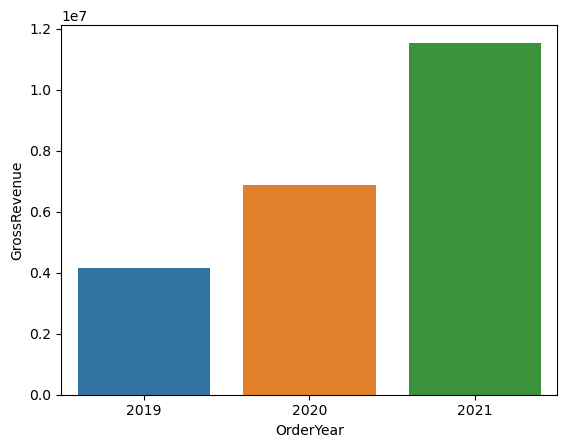

In [18]:
import seaborn as sns
import warnings

# Clear the plot area
plt.clf()

# Suppress FutureWarning from seaborn
warnings.filterwarnings('ignore', message='use_inf_as_na', category=FutureWarning)

# Create a bar chart
ax = sns.barplot(x="OrderYear", y="GrossRevenue", data=df_sales)

plt.show()

StatementMeta(, adf44236-9104-4e4e-a152-4bacb30489fd, 34, Finished, Available, Finished, False)

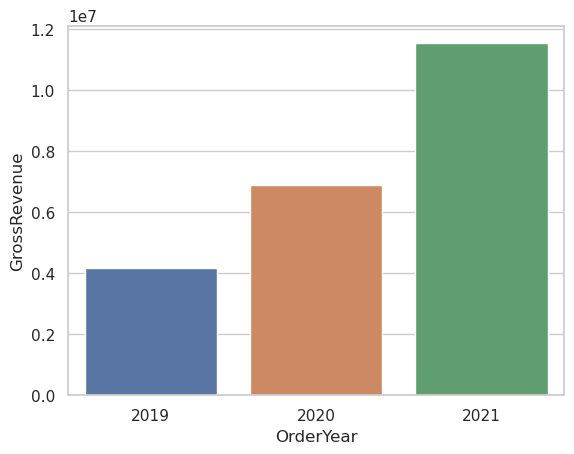

In [19]:
import seaborn as sns

# Clear the plot area
plt.clf()

# Set the visual theme for seaborn
sns.set_theme(style="whitegrid")

# Create a bar chart
ax = sns.barplot(x="OrderYear", y="GrossRevenue", data=df_sales)

plt.show()

StatementMeta(, adf44236-9104-4e4e-a152-4bacb30489fd, 37, Finished, Available, Finished, False)

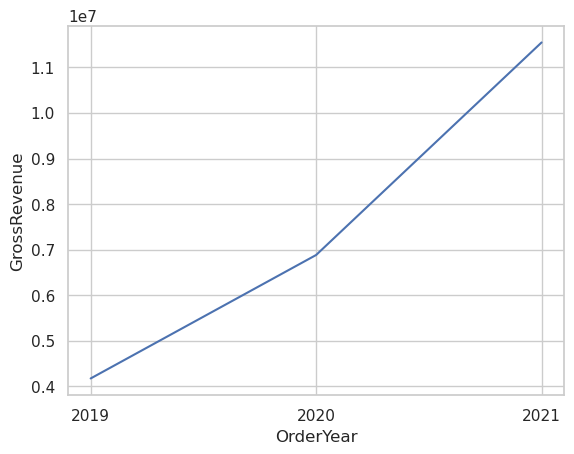

In [20]:
 import seaborn as sns

 # Clear the plot area
 plt.clf()

 # Create a line chart
 ax = sns.lineplot(x="OrderYear", y="GrossRevenue", data=df_sales)

 plt.show()